In [1]:
import pandas as pd
import numpy as np
from src.diagnostics import feature_skewness, plot_distribution, check_multicollinearity
from src.paths import FEATURES_TARGETS


# Analyzing Features of dataset their Probability Distribution and Multicollinearity

AvgBasketSize    46.180794
Monetary         23.264657
Frequency        10.153569
Recency           1.277222
Tenure           -0.387833
dtype: float64


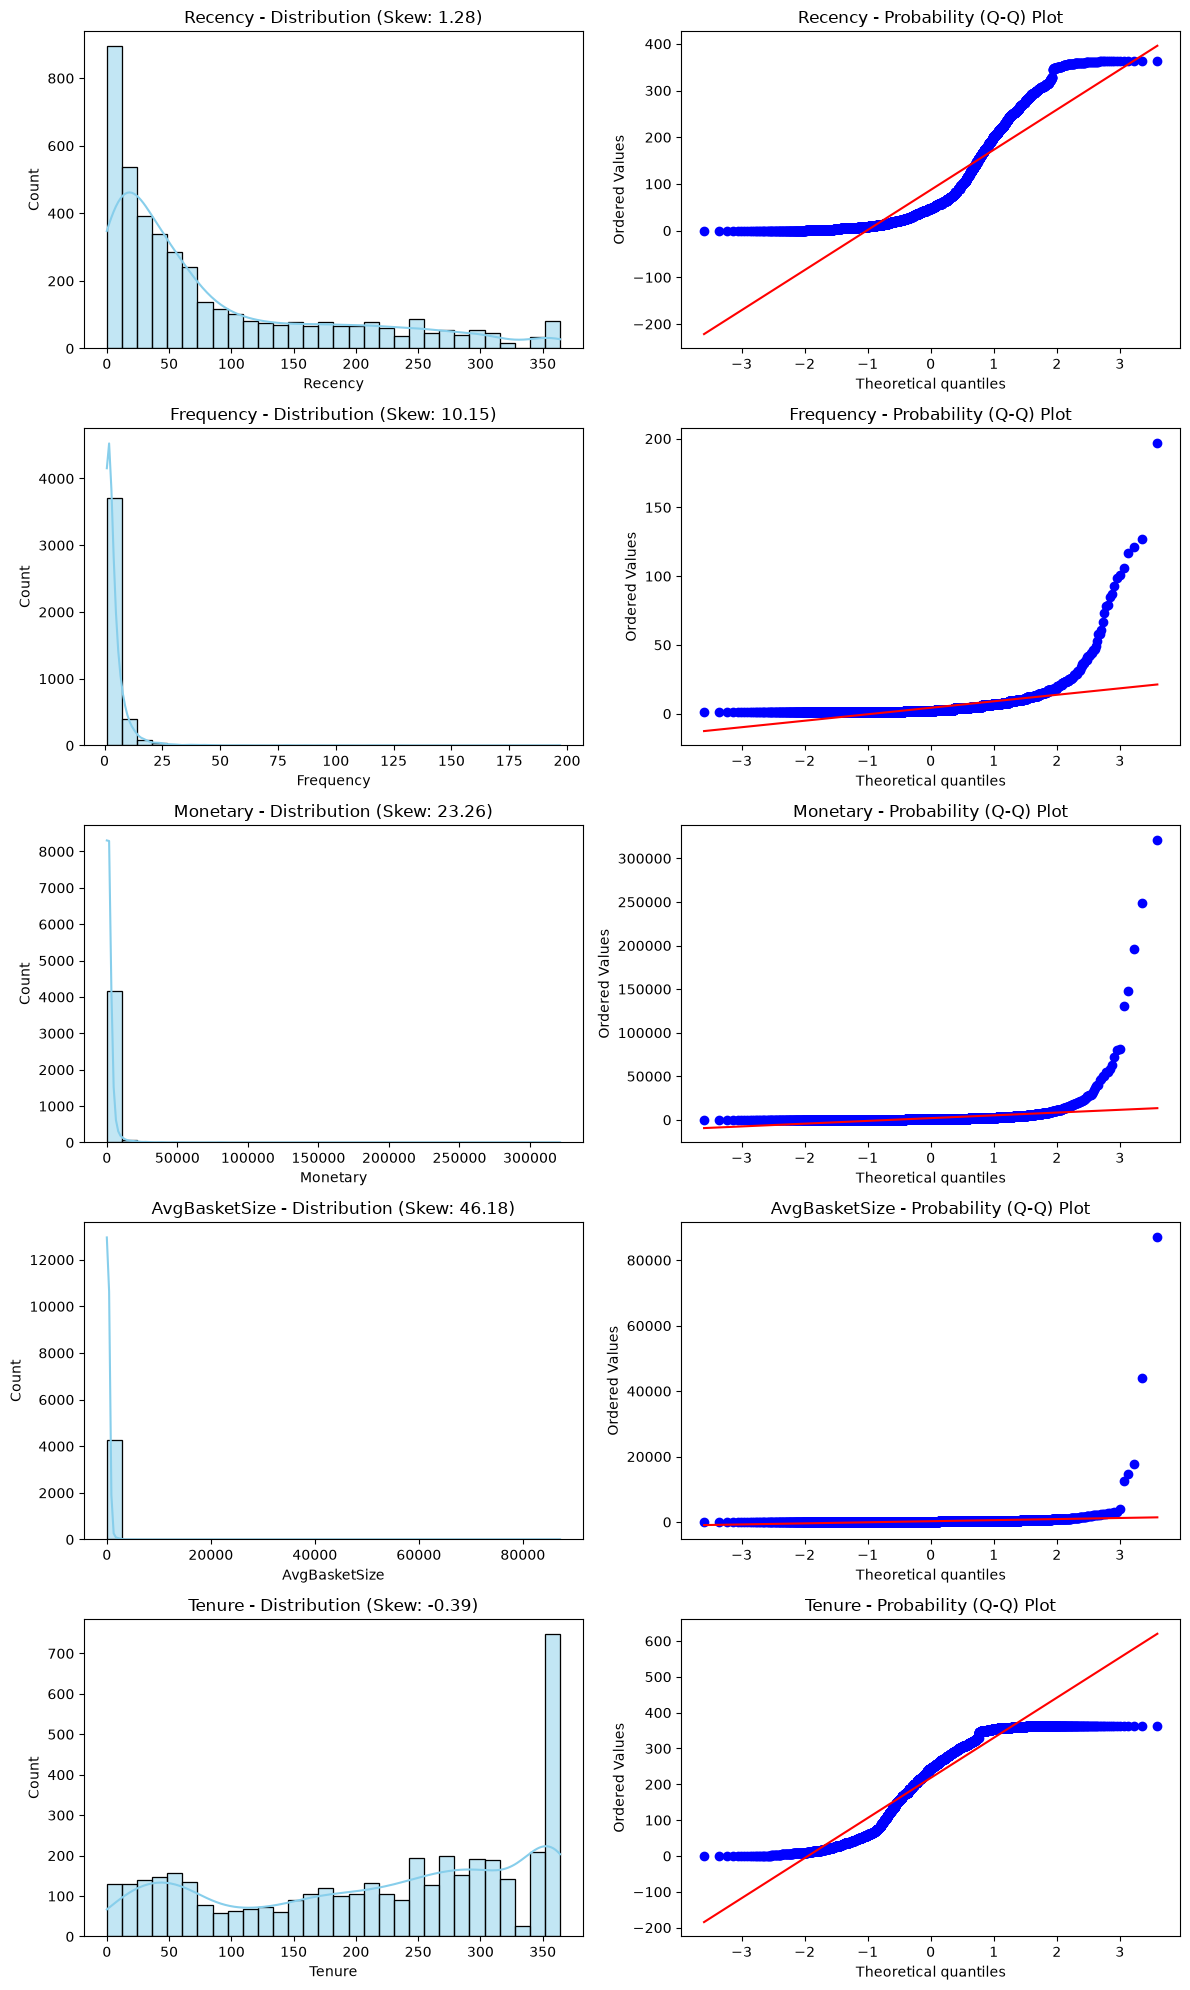

In [2]:
df = pd.read_csv(FEATURES_TARGETS)

feature_cols=["Recency", "Frequency", "Monetary", "AvgBasketSize", "Tenure"]

skewness = feature_skewness(df, feature_cols=feature_cols)
print(skewness)

plot_distribution(df, feature_cols=feature_cols)

There is Severe Right-Skewness in Moneatary, Frequency, AvgBasketSize, Recency columns to overcome this problem of sever Right-Skewness we can take monotonic transformation of log(1+x) not log(x) to avoid log(0) errors

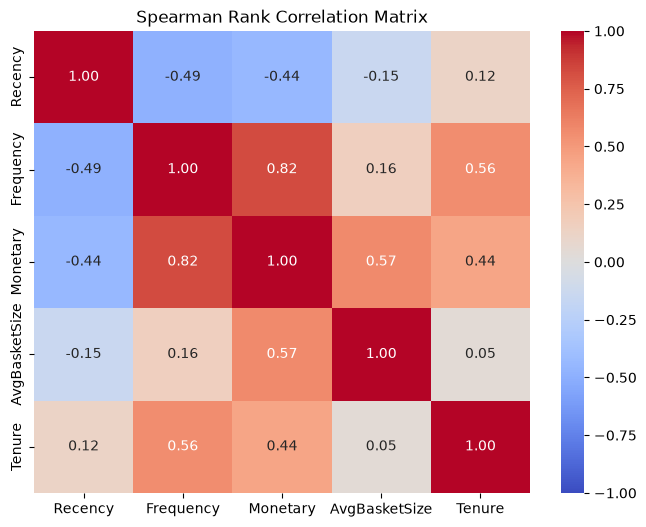

,Feature,VIF
0,Recency,2.191566
1,Frequency,2.893706
2,Monetary,1.950671
3,AvgBasketSize,1.035984
4,Tenure,3.207643


In [3]:
# Checking Multicollinearity

check_multicollinearity(df, feature_cols)

VIF for all features is <5 which doesnt create much problem. Multicollinearity exist in our dataset but not much to drop features, VIF is in acceptable range. 

# Applying Log Transformation to columns

In [4]:
df_copy = df.copy()

df_copy["AvgBasketSize"] = np.log1p(df["AvgBasketSize"])
df_copy["Monetary"] = np.log1p(df["Monetary"])
df_copy["Frequency"] = np.log1p(df["Frequency"])


Recency          1.277222
Frequency        1.200255
Monetary         0.263511
Tenure          -0.387833
AvgBasketSize   -0.692476
dtype: float64


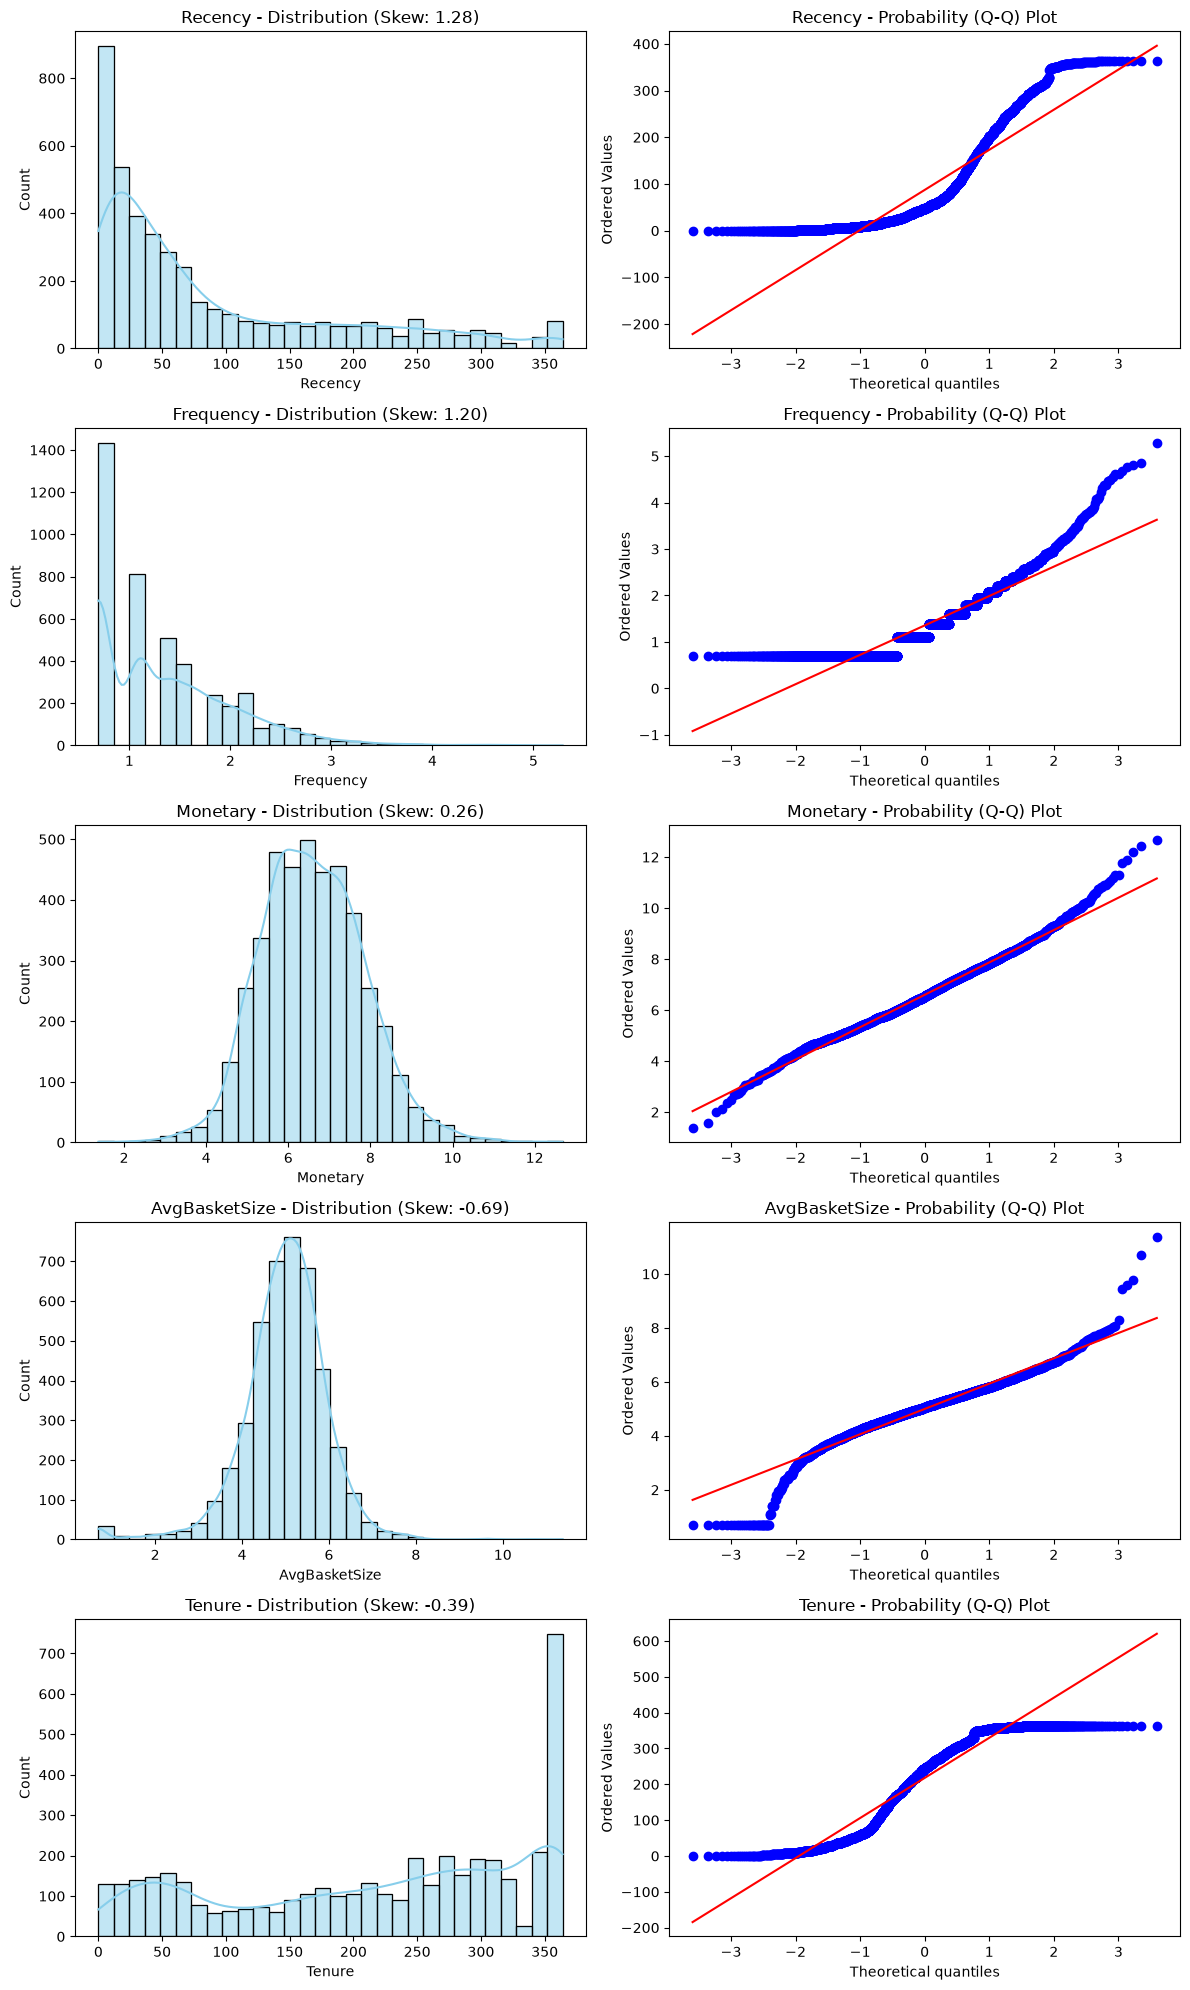

In [5]:
# Plotting the transformed columns

feature_cols_df_copy = ["Recency", "Frequency", "Monetary", "AvgBasketSize", "Tenure"]

skewness_df_copy = feature_skewness(df_copy, feature_cols=feature_cols_df_copy)
print(skewness_df_copy)
plot_distribution(df_copy, feature_cols=feature_cols_df_copy)

Intial EDA showed severe Positive Skewness in Columns AvgBasketSize, Recency, Frequency.

Skewness before transformation

1) AvgBasketSize -> 46.180794
2) Monetary -> 23.264657
3) Frequency -> 10.153569
4) Recency -> 1.277222
5) Tenure -> -0.387833

Applied log(1+x) transformation to these columns using np.log1p() 

Skewness after transformation

1) AvgBasketSize -> -0.692476
2) Monetary -> 0.263511
3) Frequency -> 1.200255
4) Recency -> 1.277222
5) Tenure -> -0.387833

The transformation has reduced Skewness substantially. The Monetary Column has taken a sweet Normal Distribution. 

Whereas Frequency and Recency Columns are still right-tail heavy. To handle that will be checking for outliers in these columns.

In [6]:
# First checking for largest values 
top_values_frequency = df_copy["Frequency"].nlargest(20)
top_values_recency = df_copy["Recency"].nlargest(20)

print(top_values_frequency)
print(top_values_recency)

1822    5.288267
246     4.852030
3959    4.804021
2111    4.770685
496     4.672829
1256    4.624973
1589    4.605170
926     4.543295
3952    4.477337
4141    4.454347
1931    4.382027
1620    4.369448
4026    4.304065
1531    4.219508
4036    4.127134
2914    4.077537
3616    4.077537
1007    3.988984
84      3.912023
500     3.871201
Name: Frequency, dtype: float64
14      364
176     364
796     364
1627    364
3148    364
3362    364
3770    364
1222    363
1735    363
1872    363
2472    363
3385    363
3782    363
3818    363
3938    363
3999    363
380     362
719     362
1402    362
1500    362
Name: Recency, dtype: int64


The largest values dont show anything of significance. 
1) Recency Column has max value of 364 becaue during feature creation it has a bound from [0, 364] so its not an outlier. 
2) Whereas even after log transformation of Frequency column skewness is still there but will retain it.

# Analyzing Target_LTV

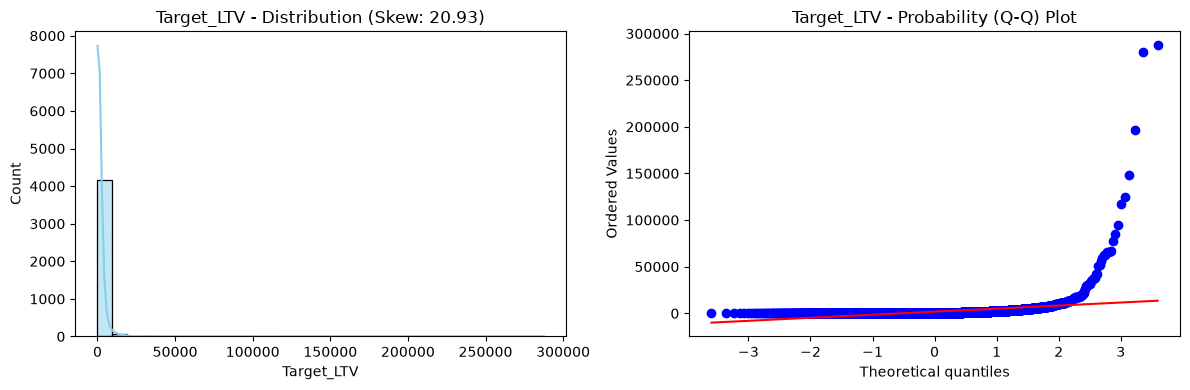

count      4266.000000
mean       1743.763257
std        8915.787898
min           0.000000
25%           0.000000
50%         329.765000
75%        1340.102500
max      287491.910000
Name: Target_LTV, dtype: float64

In [ ]:
plot_distribution(df, ["Target_LTV"]) # This is taking all 4266 customers even those whose Target_LTV in Year_2 was == 0
df["Target_LTV"].describe()

In [9]:
df.groupby("Target_churn")["Target_LTV"].describe()

,count,mean,std,min,25%,50%,75%,max
Target_churn,,,,,,,,
0,2726.0,2728.867958,11032.931413,6.9,378.6075,893.545,2262.995,287491.91
1,1540.0,0.000000,0.000000,0.0,0.0000,0.000,0.000,0.00


Out of total 4266 customers only 2726 are customers who have Target_LTV > 0 in Year_2 thus churn=0 for them. We are interested in these 2726 customers only.

count      2726.000000
mean       2728.867958
std       11032.931413
min           6.900000
25%         378.607500
50%         893.545000
75%        2262.995000
max      287491.910000
Name: Target_LTV, dtype: float64


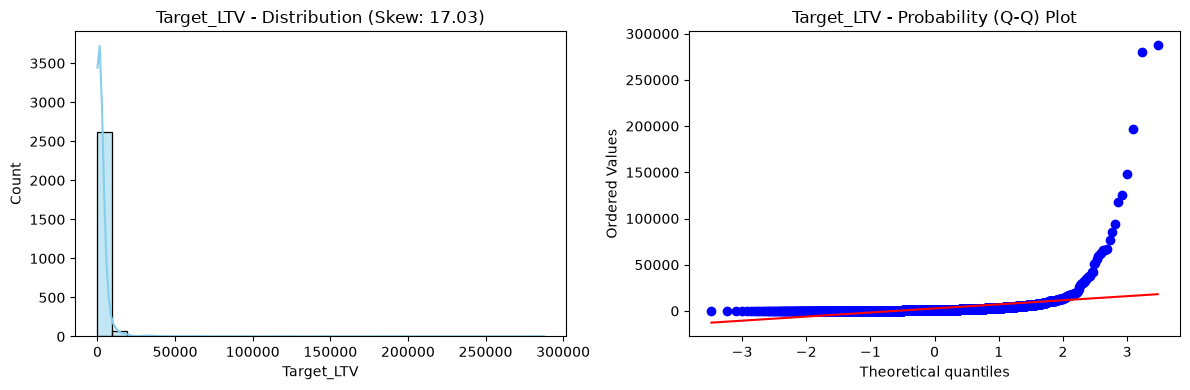

In [17]:
positive_ltv_df = df[df["Target_LTV"]>0]
print(positive_ltv_df["Target_LTV"].describe())
plot_distribution(positive_ltv_df, ["Target_LTV"])

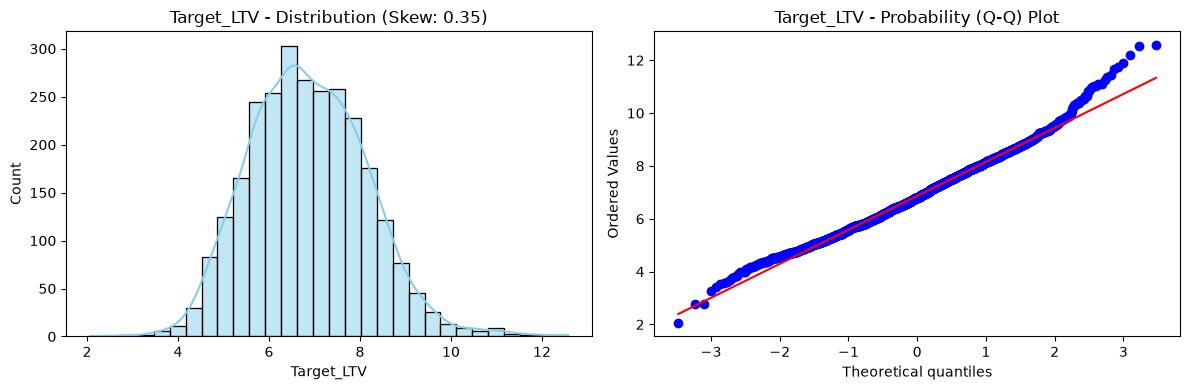

In [19]:
# Applying log1p transformation 

positive_ltv_df["Target_LTV"] = np.log1p(positive_ltv_df["Target_LTV"])
plot_distribution(positive_ltv_df, ["Target_LTV"])

So np.log1p tranformation needs to be done on Target_LTV column